In [1]:
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import VECM
from matplotlib import pyplot as plt
from sklearn.preprocessing import RobustScaler
from urllib.parse import urlencode
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
# Date locale (agregat national 2016-2025) - vezi README.
cheltuieli_df = pd.read_csv("cheltuieli_total.csv")
venituri_df = pd.read_csv("venituri_total.csv")

In [4]:
full_df = pd.merge(
  cheltuieli_df.rename(columns={'Valoare': 'Expenditure'}),
  venituri_df.rename(columns={'Data': 'data_indicatori', 'Valoare': 'Income'}),
  how='left',
  left_on='Data',
  right_on='data_indicatori'
).drop(columns=['data_indicatori']).rename(columns={'Data': 'Date'})

full_df['Date'] = pd.to_datetime(
    full_df['Date'].astype(str).str[:19],  # taie eventuale microsecunde/tz
    format='%Y-%m-%dT%H:%M:%S',
    errors='coerce'
)
full_df = full_df.dropna(subset=['Date']).sort_values('Date')

serie_df = full_df.sort_values(by='Date').reset_index(drop=True)
serie_df = (full_df
            .sort_values('Date')
            .set_index('Date')      # <<— index datetime
            .asfreq('MS')) 
scall_expenditure = RobustScaler()
scall_income = RobustScaler()
serie_df['Expenditure'] = scall_expenditure.fit_transform(serie_df[['Expenditure']])
serie_df['Income'] = scall_income.fit_transform(serie_df[['Income']])


In [5]:
train_size = int(len(serie_df) * 0.80)
train_df = serie_df.iloc[:train_size]
test_df = serie_df.iloc[train_size:]

In [6]:
cols=['Expenditure', 'Income']
vec=VECM(train_df[cols],k_ar_diff=1,coint_rank=1).fit()
fc=vec.predict(len(test_df))
y_pred=fc['Expenditure'].values if isinstance(fc,pd.DataFrame) else fc[:,cols.index('Expenditure')]
fc_df  = pd.DataFrame(fc, index=test_df.index, columns=['Expenditure','Income'])

In [7]:
def plot_ecm_results(train_df: pd.DataFrame,
                     test_df: pd.DataFrame,
                     fc,                         # DataFrame sau np.ndarray
                     k_equil: float = 1.05,      # raportul din relația de cointegrare: C_t = k * V_t
                     title_prefix: str = "ECM Model for Income and Expenditure"):
    """
    Presupune coloanele: 'Expenditure' (C) și 'Income' (V) și index datetime (lunar/anual).
    fc: DataFrame (cu aceleași coloane) sau ndarray.
    """

    # --- 1) Preia seriile istorice ---
    C_hist = train_df["Expenditure"].astype(float)
    V_hist = train_df["Income"].astype(float)

    # --- 2) Normalizează fc în două serii cu același index ca test_df ---
    C_fc = pd.Series(fc["Expenditure"].values, index=test_df.index, name="Expenditure")
    V_fc = pd.Series(fc["Income"].values, index=test_df.index, name="Income")

    # --- 3) Grafic 1: istoric + prognoză ---
    fig1, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(C_hist.index, V_hist.values, label="Income (historic)", color="#4c72b0")
    ax1.plot(C_hist.index, C_hist.values, label="Expenditure (historic)", color="#dd8452")
    ax1.plot(V_fc.index, V_fc.values, "--", label="Income (forecast)", color="#4c72b0")
    ax1.plot(C_fc.index, C_fc.values, "--", label="Expenditure (forecast)", color="#dd8452")

    ax1.set_title(f"{title_prefix}")
    ax1.set_xlabel("Year"); ax1.set_ylabel("Value")
    # Axa X doar ani
    try:
        ax1.xaxis.set_major_locator(mdates.YearLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    except Exception:
        pass
    ax1.legend()
    ax1.grid(alpha=0.3)
    fig1.tight_layout()

    # --- 4) Grafic 2: eroarea de echilibru C - k * V ---
    err_hist = C_hist - k_equil * V_hist
    err_fc   = C_fc   - k_equil * V_fc

    fig2, ax2 = plt.subplots(figsize=(10, 4))
    ax2.plot(err_hist.index, err_hist.values, label="Equilibrium error (historic)", color="#4c72b0")
    ax2.plot(err_fc.index,   err_fc.values,   "--", label="Equilibrium error (forecast)", color="#4c72b0")
    ax2.axhline(0, color="gray", linestyle="--", linewidth=1)

    ax2.set_title(f"Equilibrium error: E - {k_equil}·I")
    ax2.set_xlabel("Year"); ax2.set_ylabel("Difference")
    try:
        ax2.xaxis.set_major_locator(mdates.YearLocator())
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    except Exception:
        pass
    ax2.legend()
    ax2.grid(alpha=0.3)
    fig2.tight_layout()

    plt.show()

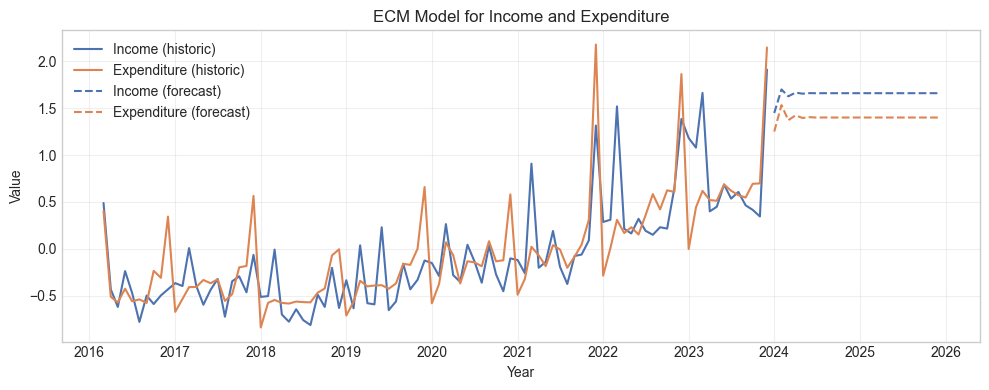

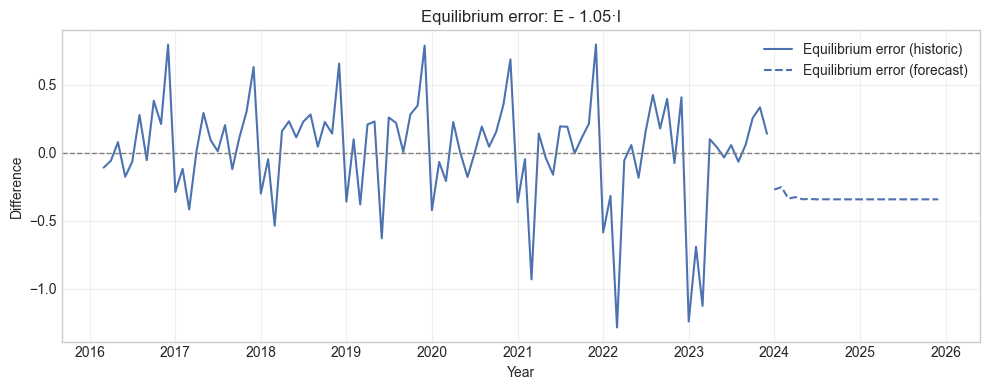

In [8]:
plot_ecm_results(train_df, test_df, fc_df, k_equil=1.05)